# Laplacian Renormalization Group (LRG) Community Detection Analysis

This notebook implements the community detection analysis using the Laplacian Renormalization Group (LRG) method on the depression population (average) structural connectivity data. The analysis includes loading and preprocessing the data, applying the LRG algorithm to identify communities (with free parameters to be chosen by the user [tau, distance_metric, threshold, criterion_name]) within the depression population structural connectivity matrix, reordering the matrix based on the identified communities, reordering all individual (from depression AND control cohorts) structural and functional matrices according to this modular structure, and visualizing the results (including producing Nifti masks for the MRIcroGL visuals). The notebook relies on helper functions defined in `LRG_modularization_utils.py` for key steps in the analysis pipeline.

Additionaly, the modules derived from this notebook are functionally (using the Yeo 7-network and Cole-Anticevic subcortical parcellations) and anatomically (Anatomical Automated Labeling SPM12 atlas) described using our inhouse compneuro-tools package (Tellaetxe-Elorriaga, 2025). For information on how to install this package and use it, see [documentation](https://github.com/itellaetxe/compneuro_tools).

Identified modules are then used as the basis for the module-level clustering and cognitive association analyses in `09_module_clustering.ipynb` and `10_module_cognitive_associations.ipynb`, respectively, and for the confirmatory analyses in `12_module_clustering_confirmatory.ipynb`.

## Imports

In [1]:
import numpy as np
import seaborn as sns
from scipy.cluster.hierarchy import fcluster
import networkx as nx
import matplotlib.pyplot as plt
import json
import sys
sys.path.insert(0, '../source_code/LRG_modularization')
from LRG_modularization_utils import *


## Configurations for the analysis
Includes paths to data and parameters for the LRG algorithm, are defined in this section. Modify the parameters as needed.

In [ ]:
# Parameters for LRG algorithm
# Matrix to modularize
modularize_A = np.load(".../data/UKB/F32_notask_STRCO_RSSCHA_RSTIA/average_structural_connectivity_matrix_streamline_count_10M.npy")
# Time parameter for diffusion process -> set this in later cell after computing 
# the graph entropy S($\tau$) because need visual inspection of the S($\tau$) curve to select 
# the optimal $\tau$ for desired detail scale for modularization
# Distance metric for hierarchical clustering
distance_metric = 'average'  # Options: 'average', 'ward', etc.
# Threshold for cutting the dendrogram to form clusters
threshold = 9 # for "maxclust" criterion the threshold is the number of clusters and for 
# "distance" criterion the threshold is the distance value to cut the dendrogram
# Criterion for forming flat clusters from the hierarchical clustering
criterion_name = "maxclust" # try "distance" and "maxclust"

# Parameters for reordering of individual subject connectivity matrices according to the modularization results
# Data dir for individual subject connectivity matrices -> also specify this in later cell
# Missing subjects files (subjects with missing connectivity matrices) -> also specify this in later cell
# Normally these files come from 03_merge_aggregate_rfMRI.ipynb and 04_aggregate_dMRI.ipynb 
# where we check for missing connectivity matrices and create a list of missing subjects. We need 
# this list to exclude the missing subjects' data folders when we reorder the individual 
# subject connectivity matrices according to the modularization results 

# Parameters for visualization of modules on nilearn brainmaps and for creating nifti masks for MRIcroGL
# Connectivity matrix (structural or functional) -> does not matter which type, just a matrix
# containing the total number of ROIs/nodes in the atlas you are using (needed for visualization
# of the modules on brainmaps and for creating nifti masks for MRIcroGL) 
conn_matrix = np.load(".../data/UKB/F32_notask_STRCO_RSSCHA_RSTIA/average_structural_connectivity_matrix_streamline_count_10M.npy")
# Path for combined nilearn figure of brainmaps with modules visualized on them
nilearn_figure_path = ".../reports/figures/schaefer1000+tian54/structural_con/modules_combined.svg"
# Path for directory where nifti masks (to be visualized in MRIcroGL) and individual nilearn mapsfor each module will be saved
masks_and_nilearn_maps_dir = ".../reports/figures/schaefer1000+tian54/structural_con/F32_modules_individual"
# Atlas file for visualization of modules on brainmaps and for creating nifti masks for MRIcroGL
atlas_file = '.../Schaefer1000_TianS4_combined.nii.gz'

## Compute the graph entropy, S($\tau$)

  0%|          | 0/1000 [00:00<?, ?it/s]/home/f_moldovan/projects/subtyping_depression/notebooks/../source_code/LRG_modularization/LRG_modularization_utils.py:50: RuntimeWarning: divide by zero encountered in log
  S[cont]=-np.nansum(T1*np.log(T1))/np.log(N)
/home/f_moldovan/projects/subtyping_depression/notebooks/../source_code/LRG_modularization/LRG_modularization_utils.py:50: RuntimeWarning: invalid value encountered in multiply
  S[cont]=-np.nansum(T1*np.log(T1))/np.log(N)
100%|██████████| 1000/1000 [00:00<00:00, 13909.70it/s]
/home/f_moldovan/projects/subtyping_depression/notebooks/../source_code/LRG_modularization/LRG_modularization_utils.py:84: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax2.legend(loc='upper right')


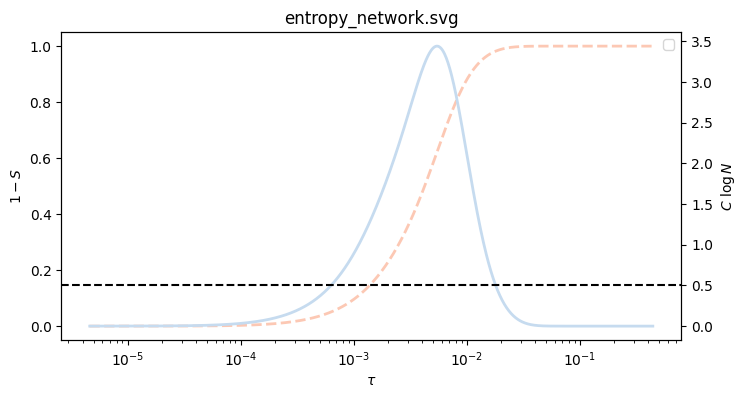

In [3]:
# Specify the matrix you want to modularize
G_network_clean = nx.from_numpy_array(modularize_A)
# Assuming G is already defined and is a NetworkX graph
G_network_clean.remove_edges_from(nx.selfloop_edges(G_network_clean))
Gcc = sorted(nx.connected_components(G_network_clean), key=len, reverse=True)
G0 = G_network_clean.subgraph(Gcc[0])

plot_entropy_network(G0, "entropy_network.svg")

## Dendrogram for fixed $\tau$ resolution

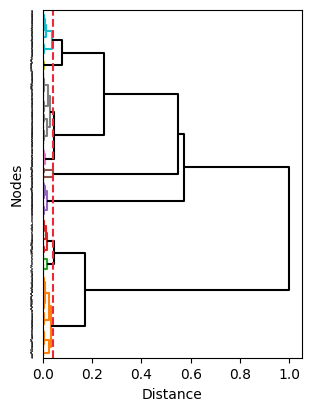

dict_items([('lvl_9_mod_1', [81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 123, 124, 125, 126, 128, 129, 130, 132, 133, 136, 137, 138, 139, 141, 143, 144, 146, 147, 149, 150, 151, 152, 154, 155, 157, 159, 160, 161, 162, 163, 164, 165, 169, 170, 171, 177, 180, 183, 190, 193, 194, 195, 196, 199, 201, 202, 203, 204, 206, 207, 208, 210, 211, 214, 218, 222, 223, 224, 225, 226, 227, 228, 229, 230, 231, 232, 233, 234, 235, 236, 237, 238, 239, 240, 241, 242, 243, 246, 247, 248, 249, 250, 251, 252, 253, 254, 255, 256, 257, 258, 259, 260, 261, 262, 263, 264, 265, 266, 267, 268, 286, 316, 318, 319, 321, 322, 323, 324, 325, 326, 327, 329, 330, 331, 334, 335, 336, 337, 338, 339, 340, 341, 342, 343, 344, 345, 346, 347, 348, 349, 350, 351, 352, 353, 354, 355, 356, 358, 359, 374, 375, 376, 377, 378, 379, 380, 381, 382, 383, 384, 386, 387, 388, 389, 391, 392, 397, 

In [4]:
tau = 10e-5 # time parameter for the diffusion process
linkage_matrix, _ = compute_dendrogram(G0, tau, distance_metric)

plot_dendrogram(linkage_matrix, threshold)
CM=fcluster(linkage_matrix, t=threshold, criterion=criterion_name)

# Save CM to a text file for later brain visualization
with open("CM.txt", "w") as f:
    for item in CM:
        f.write(f"{item}\n")

num_modules = np.max(CM)
modules = level_dictionary(CM, num_modules)

# Save modules to a text file for later analysis
with open('modules.json', 'w') as f:
    json.dump(modules, f)

print(modules.items())

## Plot modularized network

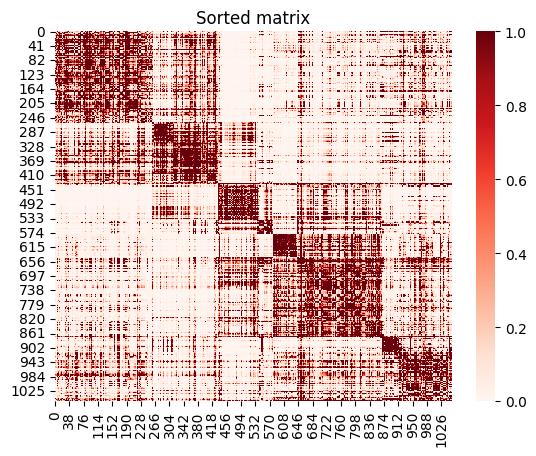

In [5]:
A_sorted, _ = reorder_matrix_by_modules(modularize_A, CM)

# Plot sorted connectivity matrix
sns.heatmap(A_sorted, cmap='Reds', vmax = 1, vmin = 0)
plt.title("Sorted matrix")
plt.savefig(f'sorted_matrix.svg')
plt.show()

## Reorder and save individual functional and structural connectivity matrices based on LRG community detection (for further modular connectivity analyses)

We also reorder the controls' individual matrices based on the community structure obtained from the F32 group to gain/force comparable modules across groups.

Processing subject 1002984...
Saved reordered connectivity matrix for subject 1002984.
Processing subject 1012868...
Saved reordered connectivity matrix for subject 1012868.
Processing subject 1021835...
Saved reordered connectivity matrix for subject 1021835.
Processing subject 1029136...
Saved reordered connectivity matrix for subject 1029136.
Processing subject 1031905...
Saved reordered connectivity matrix for subject 1031905.
Processing subject 1039409...
Saved reordered connectivity matrix for subject 1039409.
Processing subject 1040912...
Saved reordered connectivity matrix for subject 1040912.
Processing subject 1048364...
Saved reordered connectivity matrix for subject 1048364.
Processing subject 1048383...
Saved reordered connectivity matrix for subject 1048383.
Processing subject 1049974...
Saved reordered connectivity matrix for subject 1049974.
Processing subject 1055536...
Saved reordered connectivity matrix for subject 1055536.
Processing subject 1057727...
Saved reorder

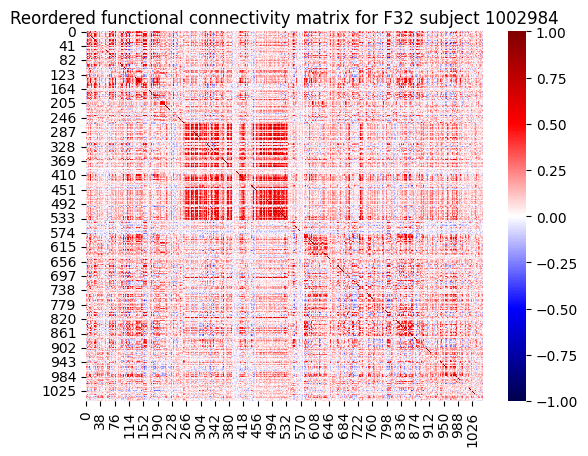

Processing subject 1002984...
Saved reordered connectivity matrix for subject 1002984.
Processing subject 1012868...
Saved reordered connectivity matrix for subject 1012868.
Processing subject 1021835...
Saved reordered connectivity matrix for subject 1021835.
Processing subject 1029136...
Saved reordered connectivity matrix for subject 1029136.
Processing subject 1031905...
Saved reordered connectivity matrix for subject 1031905.
Processing subject 1039409...
Saved reordered connectivity matrix for subject 1039409.
Processing subject 1040912...
Saved reordered connectivity matrix for subject 1040912.
Processing subject 1048364...
Saved reordered connectivity matrix for subject 1048364.
Processing subject 1048383...
Saved reordered connectivity matrix for subject 1048383.
Processing subject 1049974...
Saved reordered connectivity matrix for subject 1049974.
Processing subject 1055536...
Saved reordered connectivity matrix for subject 1055536.
Processing subject 1057727...
Saved reorder

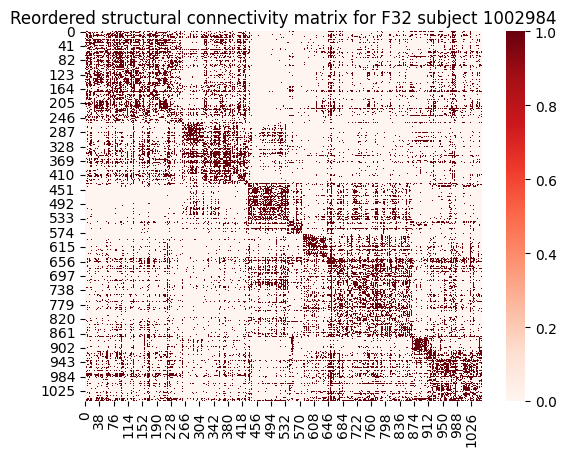

Processing subject 1000960...
Saved reordered connectivity matrix for subject 1000960.
Processing subject 1007603...
Saved reordered connectivity matrix for subject 1007603.
Processing subject 1009516...
Saved reordered connectivity matrix for subject 1009516.
Processing subject 1010827...
Saved reordered connectivity matrix for subject 1010827.
Processing subject 1033115...
Saved reordered connectivity matrix for subject 1033115.
Processing subject 1035167...
Saved reordered connectivity matrix for subject 1035167.
Processing subject 1035421...
Saved reordered connectivity matrix for subject 1035421.
Processing subject 1036443...
Saved reordered connectivity matrix for subject 1036443.
Processing subject 1038628...
Saved reordered connectivity matrix for subject 1038628.
Processing subject 1040011...
Saved reordered connectivity matrix for subject 1040011.
Processing subject 1048754...
Saved reordered connectivity matrix for subject 1048754.
Processing subject 1050168...
Saved reorder

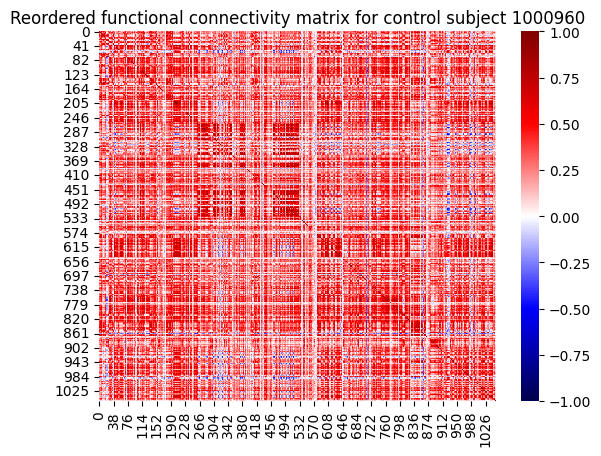

Processing subject 1000960...
Saved reordered connectivity matrix for subject 1000960.
Processing subject 1007603...
Saved reordered connectivity matrix for subject 1007603.
Processing subject 1009516...
Saved reordered connectivity matrix for subject 1009516.
Processing subject 1010827...
Saved reordered connectivity matrix for subject 1010827.
Processing subject 1033115...
Saved reordered connectivity matrix for subject 1033115.
Processing subject 1035167...
Saved reordered connectivity matrix for subject 1035167.
Processing subject 1035421...
Saved reordered connectivity matrix for subject 1035421.
Processing subject 1036443...
Saved reordered connectivity matrix for subject 1036443.
Processing subject 1038628...
Saved reordered connectivity matrix for subject 1038628.
Processing subject 1040011...
Saved reordered connectivity matrix for subject 1040011.
Processing subject 1048754...
Saved reordered connectivity matrix for subject 1048754.
Processing subject 1050168...
Saved reorder

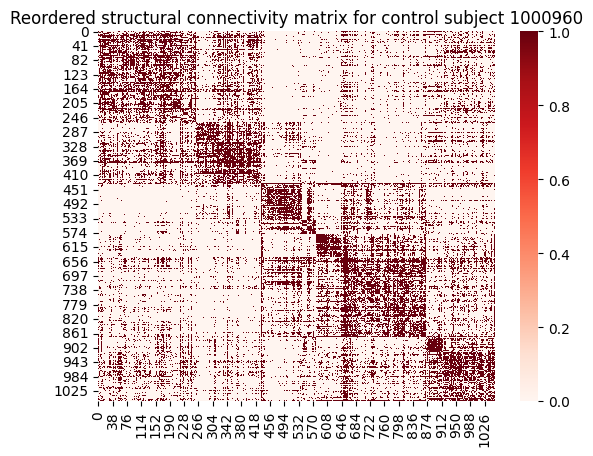

In [ ]:
for cohort in ["F32", "control"]:
    for conn_type in ['functional', 'structural']:
        data_dir = f".../data/UKB/{cohort}_notask_STRCO_RSSCHA_RSTIA"
        missing_subjects_file = f".../data/UKB/{cohort}_notask_STRCO_RSSCHA_RSTIA/missing_subjects_resting_state_timeseries.csv"
        individual_reordering_by_modules(data_dir=data_dir, 
                                        CM=CM, 
                                        missing_subjects_file=missing_subjects_file,
                                        connectivity_type=conn_type)
        # Plot one example
        if cohort == "F32":
            example_subject_id = "..."
        else:
            example_subject_id = "..."
        
        if conn_type == 'functional':
            cmap = 'seismic'
            vmin = -1
        else:
            cmap = 'Reds'
            vmin = 0
        example_matrix = np.load(f".../data/UKB/{cohort}_notask_STRCO_RSSCHA_RSTIA/{example_subject_id}/i2/{example_subject_id}_{conn_type}_connectivity_matrix_reordered.npy")
        sns.heatmap(example_matrix, cmap=cmap, vmax = 1, vmin = vmin)
        plt.title(f"Reordered {conn_type} connectivity matrix for {cohort} subject {example_subject_id}")
        plt.savefig(f'.../reports/figures/{cohort}_{conn_type}_reordered.svg')
        plt.show()

## Vizualize the modules on nilearn brainmaps and compute nifti masks for each module to be visualized in MRIcroGL

In [ ]:
with open(".../notebooks/CM.txt", "r") as f:
        lines = f.readlines()
community_labels = [int(line.strip()) for line in lines]

plot_all_communities_figure(conn_matrix, community_labels, atlas_file, nilearn_figure_path, output_dir=masks_and_nilearn_maps_dir, background_white=True)

[SAVE] /home/f_moldovan/projects/subtyping_depression/reports/figures/schaefer1000+tian54/structural_con/F32_modules_individual/module_01_mask.nii.gz
[SAVE] /home/f_moldovan/projects/subtyping_depression/reports/figures/schaefer1000+tian54/structural_con/F32_modules_individual/module_02_mask.nii.gz
[SAVE] /home/f_moldovan/projects/subtyping_depression/reports/figures/schaefer1000+tian54/structural_con/F32_modules_individual/module_03_mask.nii.gz
[SAVE] /home/f_moldovan/projects/subtyping_depression/reports/figures/schaefer1000+tian54/structural_con/F32_modules_individual/module_04_mask.nii.gz
[SAVE] /home/f_moldovan/projects/subtyping_depression/reports/figures/schaefer1000+tian54/structural_con/F32_modules_individual/module_05_mask.nii.gz
[SAVE] /home/f_moldovan/projects/subtyping_depression/reports/figures/schaefer1000+tian54/structural_con/F32_modules_individual/module_06_mask.nii.gz
[SAVE] /home/f_moldovan/projects/subtyping_depression/reports/figures/schaefer1000+tian54/structural

## Functional and anatomical description of identified modules

Ensure you have followed installation and usage instructions for the [compneuro-tools package](https://github.com/itellaetxe/compneuro_tools).

Paste the following code into a terminal to reproduce the functional and anatomical descriptions of the identified modules. Adjust paths and parameters as needed.

### Functional description of modules using Yeo 7-network parcellation

NILEARN_DATA=.../nilearn_data PYTHONPATH=.../projects/subtyping_depression/external/compneuro_tools/src .../venvs/.neurovenv/bin/python -m compneuro_tools.atlas_overlap --input_mask .../module_01_mask.nii.gz --atlas_name 'yeo7' --yeo7_thickness thick  --reference 'mask'

### Functional description of modules using Cole-Anticevic subcortical parcellation

NILEARN_DATA=.../nilearn_data PYTHONPATH=.../projects/subtyping_depression/external/compneuro_tools/src .../venvs/.neurovenv/bin/python -m compneuro_tools.atlas_overlap --input_mask .../module_01_mask.nii.gz --atlas_name 'ColeAnticevicSubcortical' --reference 'mask'

### Anatomical description of modules using AAL parcellation

NILEARN_DATA=.../nilearn_data PYTHONPATH=.../projects/subtyping_depression/external/compneuro_tools/src .../venvs/.neurovenv/bin/python -m compneuro_tools.atlas_overlap --input_mask .../module_01_mask.nii.gz --atlas_name 'aal_spm12' --reference 'mask'
